In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import MDS 
import glob
import math
import matplotlib.pyplot as plt
from Clustering_Functions import *

In [2]:
df = pd.read_pickle('results.pkl')

In [3]:
# add column 'portion_of_complete_ballots'
ls = []
for count in range(len(df)):
    portion = df['ballot_lengths'][count][df['num_cands'][count]]/df['num_voters'][count]
    ls.append(portion)
df['portion_complete_ballots'] = ls

In [4]:
# add column 'bloc_size' = minimum of the two bloc sizes.
ls = []
for row in range(len(df)):
    ls.append(min(df['block_size'][row],1-df['block_size'][row]))
df['bloc_size'] = ls

In [5]:
# list of elections, list of clustering methods
filenames = df['filename'].unique()
method_list = df['method'].unique()

# We ran each clustering method TWICE on each election.
# So we'll add a 'trial_num' column with entries {0,1}
df['trial_num'] = 0
for filename in filenames:
    for method in method_list:
        dfs = df[(df['filename']==filename) & (df['method'] == method)]
        indices = dfs.index # list of the two row numbers (indices) of dfs
        df['trial_num'][indices[1]]=1 # because 0 is already set to 0.

C:\Users\ktapp\AppData\Local\Temp\ipykernel_44044\1270382999.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['trial_num'][indices[1]]=1 # because 0 is already set to 0.


In [28]:
df0 = df[df['trial_num'] == 0]  # only the first trial of each method
dfs = df0.dropna(subset = ['slates']) # only the first slate trial of each election
# note that dfs has one row for each election, and hense is good for gathering data that doesn't involve clustering.

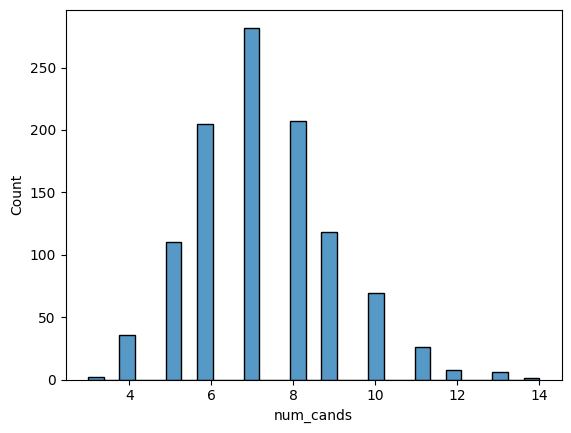

In [7]:
fig = sns.histplot(dfs['num_cands'])
fig.figure.savefig("plots/num_cands.jpg", dpi = 600)

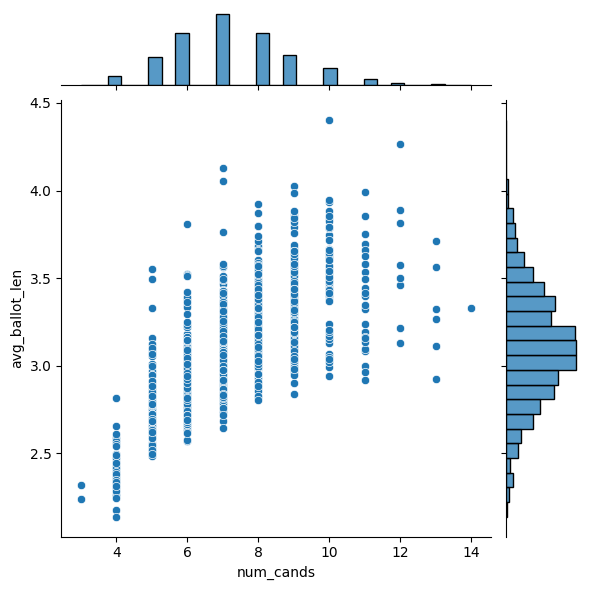

In [8]:
fig = sns.jointplot(dfs, x='num_cands', y='avg_ballot_len')
fig.figure.savefig("plots/num_cands_vs_bal_len.jpg", dpi = 600)

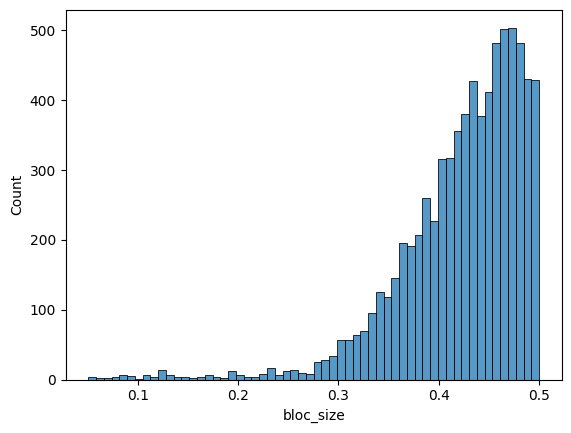

In [9]:
fig = sns.histplot(data = df0, x = 'bloc_size')
fig.figure.savefig("plots/block_size.jpg", dpi = 600)

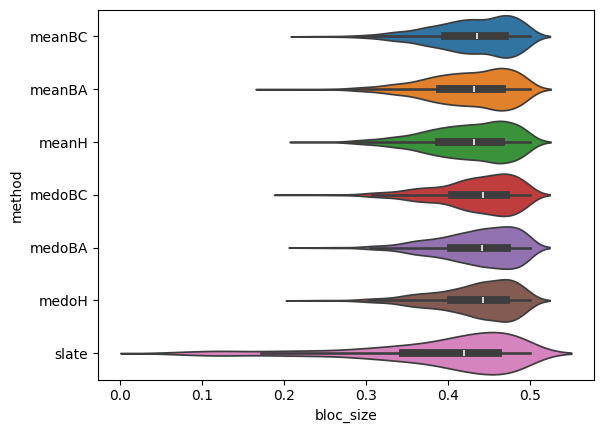

In [10]:
fig = sns.violinplot(data = df0, x = 'bloc_size', y='method', hue='method')
fig.figure.savefig("plots/sperm_race.jpg", dpi = 600)

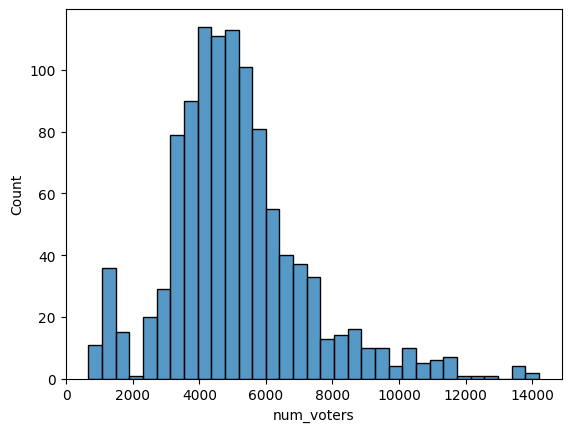

In [11]:
fig = sns.histplot(data=dfs, x = 'num_voters')
fig.figure.savefig("plots/num_voters.jpg", dpi = 600)

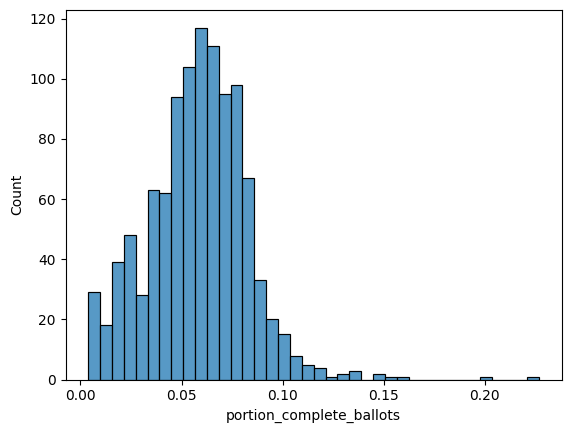

In [12]:
fig = sns.histplot(data = dfs, x = 'portion_complete_ballots')
fig.figure.savefig("plots/portion_complete_ballots.jpg", dpi = 600)

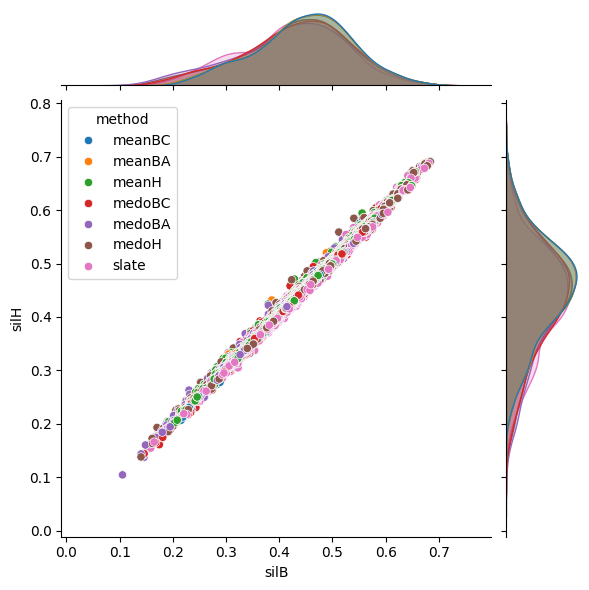

In [13]:
fig = sns.jointplot(data=df0, x='silB',y='silH', hue = 'method')
fig.figure.savefig("plots/silB_vs_silH.jpg", dpi = 600)

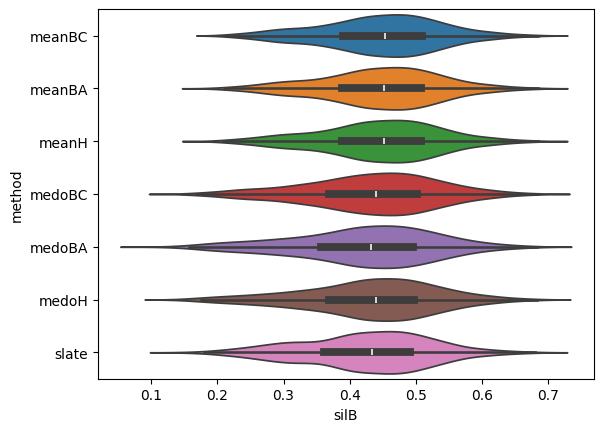

In [14]:
fig = sns.violinplot(data=df0, x = 'silB', y = 'method', hue = 'method')
fig.figure.savefig("plots/methd_vs_silB_violin.jpg", dpi = 600)

In [15]:
# Euclidean distance between centroids (dictionaries), summed over the two partition pieces
# wrt the best match between the two pieces of the first clustering and of the second.

def Distance_between_centroids(C1,C2):
    d1 = np.linalg.norm(C1[0]-C2[0]) + np.linalg.norm(C1[1]-C2[1])
    d2 = np.linalg.norm(C1[0]-C2[1]) + np.linalg.norm(C1[1]-C2[0])
    return min(d1,d2)

In [16]:
# Next we'll compare different clustering methods differ
# with differences measured as the distance between their Borda-ceontriods.
# we'll gather the results in a 7-by-7 table

delta = pd.DataFrame(index = method_list, columns=method_list)

proxy = 'centroids_B'
for m1 in method_list:
    for m2 in method_list:
        #print(m1,m2)
        if m1==m2:
            i1,i2 = 0,1
        else:
            i1,i2 = 0,0
        summed_dist = 0
        for filename in filenames:
            dfr = df[(df['filename']==filename) & (df['method'] == m1)]
            indices = dfr.index
            C1 = dfr[proxy][indices[i1]]
            
            dfr = df[(df['filename']==filename) & (df['method'] == m2)]
            indices = dfr.index
            C2 = dfr[proxy][indices[i2]]           
        
            dist =  Distance_between_centroids(C1,C2)
            summed_dist += dist
        delta[m1][m2] = summed_dist/len(filenames)
delta.to_csv('tables\centroid_difs.csv')
delta 

,meanBC,meanBA,meanH,medoBC,medoBA,medoH,slate
meanBC,0.001128,0.302144,0.330662,1.418977,1.575703,1.447049,2.110798
meanBA,0.302144,0.000767,0.074796,1.435545,1.559056,1.450227,2.169162
meanH,0.330662,0.074796,0.000585,1.436827,1.552451,1.44702,2.188802
medoBC,1.418977,1.435545,1.436827,0.320832,0.943898,0.700943,2.419342
medoBA,1.575703,1.559056,1.552451,0.943898,0.208062,0.886784,2.593173
medoH,1.447049,1.450227,1.44702,0.700943,0.886784,0.26805,2.521672
slate,2.110798,2.169162,2.188802,2.419342,2.593173,2.521672,0.0


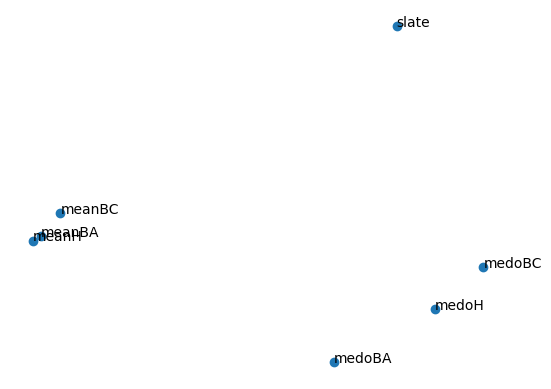

<Figure size 640x480 with 0 Axes>

In [17]:
projections = MDS(n_components=2, dissimilarity='precomputed').fit_transform(delta)
X = np.array([p[0] for p in projections])
Y = np.array([p[1] for p in projections])
fig, ax = plt.subplots()
ax.scatter(X,Y)
for count in range(len(method_list)):
    ax.annotate(method_list[count], xy=(X[count], Y[count]))
ax.grid(False)
ax.axis('off')
plt.show()
plt.savefig("plots/method_MDS_euclid", dpi = 600)

In [18]:
# Next let's do it again with distance measured as the
# portion of elections in which the centroids are NOT exacty the same.

same_centroids = pd.DataFrame(index = method_list, columns=method_list)

proxy = 'centroids_B'
for m1 in method_list:
    for m2 in method_list:
        #print(m1,m2)
        if m1==m2:
            i1,i2 = 0,1
        else:
            i1,i2 = 0,0
        dif_count = 0
        for filename in filenames:
            dfr = df[(df['filename']==filename) & (df['method'] == m1)]
            indices = dfr.index
            C1 = dfr[proxy][indices[i1]]
            
            dfr = df[(df['filename']==filename) & (df['method'] == m2)]
            indices = dfr.index
            C2 = dfr[proxy][indices[i2]]           
        
            dist =  Distance_between_centroids(C1,C2)
            if dist != 0:
                dif_count +=1
            
        same_centroids[m1][m2] = dif_count/len(filenames)
same_centroids.to_csv('tables\same_centroids.csv')
same_centroids      

,meanBC,meanBA,meanH,medoBC,medoBA,medoH,slate
meanBC,0.035514,0.972897,0.976636,1.0,1.0,0.999065,0.998131
meanBA,0.972897,0.025234,0.88785,1.0,1.0,1.0,0.998131
meanH,0.976636,0.88785,0.027103,1.0,1.0,0.999065,0.998131
medoBC,1.0,1.0,1.0,0.085981,1.0,0.992523,0.999065
medoBA,1.0,1.0,1.0,1.0,0.053271,1.0,1.0
medoH,0.999065,1.0,0.999065,0.992523,1.0,0.064486,1.0
slate,0.998131,0.998131,0.998131,0.999065,1.0,1.0,0.0


In [19]:
# Next let's do it again with distance measured as the
# portion of elections in which the MEDOIDS are NOT exacty the same.

same_medoids = pd.DataFrame(index = method_list, columns=method_list)

proxy = 'medoids_B'
for m1 in method_list:
    for m2 in method_list:
        #print(m1,m2)
        if m1==m2:
            i1,i2 = 0,1
        else:
            i1,i2 = 0,0
        dif_count = 0
        for filename in filenames:
            dfr = df[(df['filename']==filename) & (df['method'] == m1)]
            indices = dfr.index
            C1 = dfr[proxy][indices[i1]]
            
            dfr = df[(df['filename']==filename) & (df['method'] == m2)]
            indices = dfr.index
            C2 = dfr[proxy][indices[i2]]           
        
            if not ((C1[0]==C2[0] and C1[1]==C2[1]) or (C1[0]==C2[1] and C1[1]==C2[0])): 
                dif_count +=1
            
        same_medoids[m1][m2] = dif_count/len(filenames)
same_medoids.to_csv('tables\same_medoids.csv')
same_medoids

,meanBC,meanBA,meanH,medoBC,medoBA,medoH,slate
meanBC,0.0,0.092523,0.095327,0.271963,0.318692,0.281308,0.347664
meanBA,0.092523,0.000935,0.033645,0.283178,0.298131,0.278505,0.358879
meanH,0.095327,0.033645,0.0,0.285981,0.291589,0.273832,0.360748
medoBC,0.271963,0.283178,0.285981,0.085981,0.318692,0.250467,0.376636
medoBA,0.318692,0.298131,0.291589,0.318692,0.053271,0.280374,0.440187
medoH,0.281308,0.278505,0.273832,0.250467,0.280374,0.064486,0.407477
slate,0.347664,0.358879,0.360748,0.376636,0.440187,0.407477,0.0


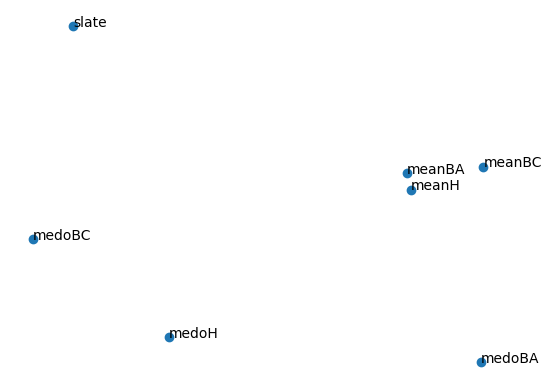

<Figure size 640x480 with 0 Axes>

In [20]:
projections = MDS(n_components=2, dissimilarity='precomputed').fit_transform(same_medoids)
X = np.array([p[0] for p in projections])
Y = np.array([p[1] for p in projections])
fig, ax = plt.subplots()
ax.scatter(X,Y)
for count in range(len(method_list)):
    ax.annotate(method_list[count], xy=(X[count], Y[count]))
ax.grid(False)
ax.axis('off')
plt.show()
plt.savefig("plots/method_MDS_medoids", dpi = 600)

In [30]:
# create a dictionary, called party_dict, matching party codes to party full names
# (including all parties in all elections)

def Party_code_and_fullname(input_string):
    start_idx = input_string.find('(')
    end_idx = input_string.find(')')
    if start_idx != -1 and end_idx != -1:
        A = input_string[start_idx + 1:end_idx]
        B = input_string[:start_idx].strip() + input_string[end_idx + 1:].strip()
        return A, B
    else:
        return None, input_string

party_dict = dict()

for index in range(len(dfs)):
    pdict = dfs.iloc[index]['parties']
    for party in pdict.values():
        code,full_name = Party_code_and_fullname(party)
        # first check for codes associated to more than one full name.
        if code in party_dict.keys():
            if party_dict[code] != party:
                raise Exception(code, full_name, party_dict[code])
        else:
            party_dict[code] = party

In [34]:
# create a dictionary matching party codes to the portion of total Borda points
# received by all candidates from that party in all elections.
party_to_borda={code:0 for code in party_dict.keys()}

for rownum in range(len(dfs)):
    pdict = dfs.iloc[rownum]['parties']
    Borda_scores = sum(dfs.iloc[rownum]['centroids_B'].values())
    for index in pdict.keys():
        code, full_name = Party_code_and_fullname(pdict[index])
        party_to_borda[code] += Borda_scores[index-1]

# scale the values to become percentage of all Borda points
total_weight = sum(party_to_borda.values())
for code, weight in party_to_borda.items():
    party_to_borda[code] = 100*weight/total_weight

In [38]:
# print the parties sorted by total Borda weight

def print_sorted(input_dict):
    # Sort the dictionary by values
    sorted_items = sorted(input_dict.items(), key=lambda item: item[1], reverse=True)
    
    # Print the sorted dictionary
    for key, value in sorted_items:
        print(f"{key}: {value}")

print_sorted(party_to_borda)

SNP: 29.190386894546904
Lab: 21.25038700380674
Ind: 16.09970268040257
Con: 13.251385558388083
LD: 8.844130032274018
Gr: 6.422960514973758
LabCo: 0.6099075912599686
API: 0.5689466612022411
Soc: 0.4873079791400124
UKIP: 0.4603896860393266
TUSC: 0.36890888425855767
SFP: 0.3542319225023746
Sol: 0.33753573622645955
Glasgow First: 0.20482568486771657
SC: 0.17712811741833703
SU: 0.17149254523194676
Libtn: 0.14771222702155873
SSC: 0.12030965873856644
Borders: 0.11366726904390037
SLP: 0.08495386575407392
IANL: 0.07807406696498483
ISP: 0.0714574922420097
WDuns: 0.06806906762379056
FA: 0.04044634002663776
Lib: 0.03962386520363444
OMG: 0.03784656043857014
NF: 0.03293166299613537
NRMUPB: 0.030313393240118443
EDIA: 0.030143492361948722
CICA: 0.028404085642404733
Rubbish: 0.027601378845503195
EKA: 0.02752363416876398
Pir: 0.02629014565813736
SDP: 0.023503295061818256
Sov: 0.021171692990409607
BNP: 0.020534212965752387
WEP: 0.020100731412213923
BP: 0.01946996636986035
CPA: 0.014303796172881168
Comm: 0

In [45]:
top_parties = ['SNP', 'Lab', 'Ind', 'Con', 'LD', 'Gr']
scores = [party_to_borda[code] for code in top_parties]
top_parties.append('other')
scores.append(sum(x for x in party_to_borda.values() if x<=1))
D = {'SNP':'yellow', 'Lab': 'red', 'Con':'blue','LD':'orange','Gr':'green', "Ind":'black', 'other':'white'}
colors = [D[party] for party in top_parties]

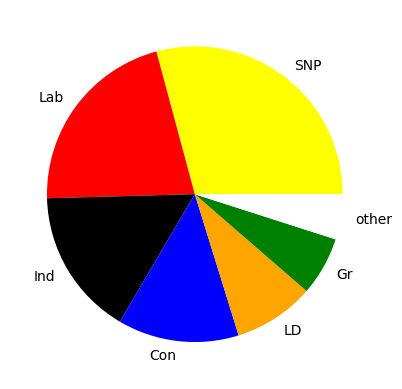

In [47]:
plt.pie(scores, labels = top_parties, colors=colors)
plt.savefig("plots/pie.jpg", dpi = 600)

In [50]:
# add a column 'portion_of_graph_covered'
def F(n):
    return math.floor(np.exp(1)*math.factorial(n)-1)

ls = []
for count in range(len(df)):
    num_cands = df['num_cands'][count]
    num_bal = df['num_unique_ballots'][count]
    portion = num_bal/F(num_cands)
    ls.append(portion)
df['portion_of_graph_covered'] = ls

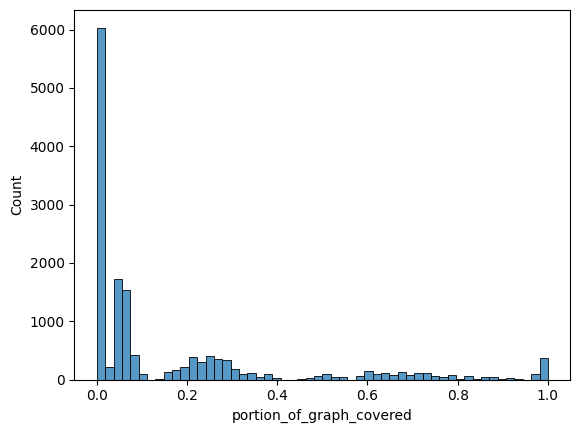

In [53]:
fig = sns.histplot(data = df, x = 'portion_of_graph_covered')
fig.figure.savefig("plots/portion_portion_of_graph_covered.jpg", dpi = 600)

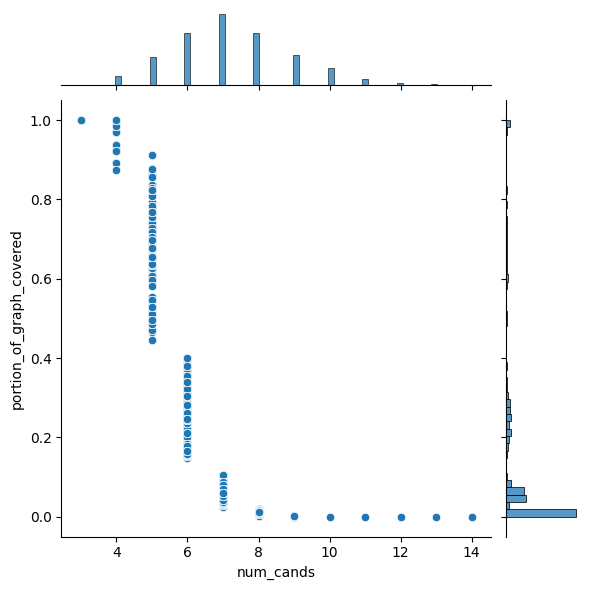

In [68]:
fig = sns.jointplot(data = df, x = 'num_cands', y = 'portion_of_graph_covered')
fig.figure.savefig('plots/num_cands_vs_portion_covered.jpg', dpi=600)

In [56]:
# find the avg portion of graph covered among elections with each choice of num_cands

for count in range(13):
    d = df[df['num_cands'] == count]
    p = np.mean(d['portion_complete_ballots'])
    print(count,p)

0 nan
1 nan
2 nan
3 0.008598117831063361
4 0.009300748501400434
5 0.026596452277013908
6 0.05073919821196347
7 0.06560199490007185
8 0.0729682689459772
9 0.07062990452593518
10 0.0687691370410793
11 0.04889971163959394
12 0.05545848066503088


In [67]:
# Create table showing the number of elections in which each major party ran each number of candidates.

top_parties = ['SNP', 'Lab', 'Ind', 'Con', 'LD', 'Gr']
data = np.zeros((6,11))
filename_list = glob.glob("scot-elex/**/*.csv")

for filename in filename_list:
    num_cands, election, cand_names, location = csv_parse(filename)
    party_list = party_abrevs(cand_names)
    for party_index in range(len(top_parties)):
        party = top_parties[party_index]
        count = party_list.count(party)
        data[party_index,count] +=1

trunc_data = data[:,:8]
pf = pd.DataFrame(trunc_data, index = top_parties, columns=range(8))
pf.to_csv('tables\How_many_candidates_does_the_party_run.csv')
pf


,0,1,2,3,4,5,6,7
SNP,32.0,322.0,658.0,57.0,1.0,0.0,0.0,0.0
Lab,166.0,465.0,405.0,34.0,0.0,0.0,0.0,0.0
Ind,427.0,323.0,153.0,83.0,31.0,25.0,13.0,9.0
Con,55.0,867.0,138.0,10.0,0.0,0.0,0.0,0.0
LD,332.0,700.0,36.0,2.0,0.0,0.0,0.0,0.0
Gr,508.0,562.0,0.0,0.0,0.0,0.0,0.0,0.0
